# Seller Revenue EDA
EDA on the relationship between revenue and states

## Objective
- Do different states have significant impact on revenue?
- What do the revenue distribution for each state look like?
- Other relevant insights

## Approach
- Select the most relevant states for analysis. Combine other unselected states into an Other category. Selection by record count is used due to a lot of states having very low record counts 
- Visualize counts, sum, mean, and distribution for revenue by state for insights
- Perform statistical test to validate the state effects on revenue (selection based on previous analysis)

## Selected States for Analysis
Selection is based on the record count.

  | State | Record Count |
  | --| --|
  | SP | 1751 |
  | PR | 334 |
  | MG | 235 |
  | SC | 184 |
  | RJ | 161 |
  | Other | 158 |
  | RS | 122 |

## Key Findings
- SP is the dominant seller state, accounting for 64.6% of total revenue. No other state comes close, with PR as the next largest at 9.2%.
- All states follow the same revenue distribution pattern, with no state showing unusual behavior.
- SP clearly drives revenue. Among all other states, revenue performance is comparable with no meaningful differences between them.

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal
from pathlib import Path

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))

from data.connection import get_connection
from utils.plots import plot_cat, plot_distribution, plot_boxplot_by_group, plot_kde_by_group

conn = get_connection()

In [2]:
with open(f"{ROOT}/sql/seller_revenue.sql") as f:
    sql = f.read()

df = pd.read_sql(sql, conn)

df = df.astype({
    "seller_id": str,
    "seller_state": str,
    "revenue": float,
})

df.head()

,seller_id,seller_state,revenue
0,0015a82c2db000af6aaaf3ae2ecb0532,SP,2748.06
1,001cca7ae9ae17fb1caed9dfb1094831,ES,33142.90
2,002100f778ceb8431b7a1020ff7ab48f,SP,1995.16
3,003554e2dce176b5555353e4f3555ac8,GO,139.38
4,004c9cd9d87a3c30c522c48c4fc07416,SP,23094.02


## Overview
An initial look across all seller states shows a highly uneven distribution. SP dominates across all metrics. The count of sellers drops sharply after the top 6 states, making the remaining states unreliable for analysis without grouping.

### Count, Mean, and Total Revenue by State

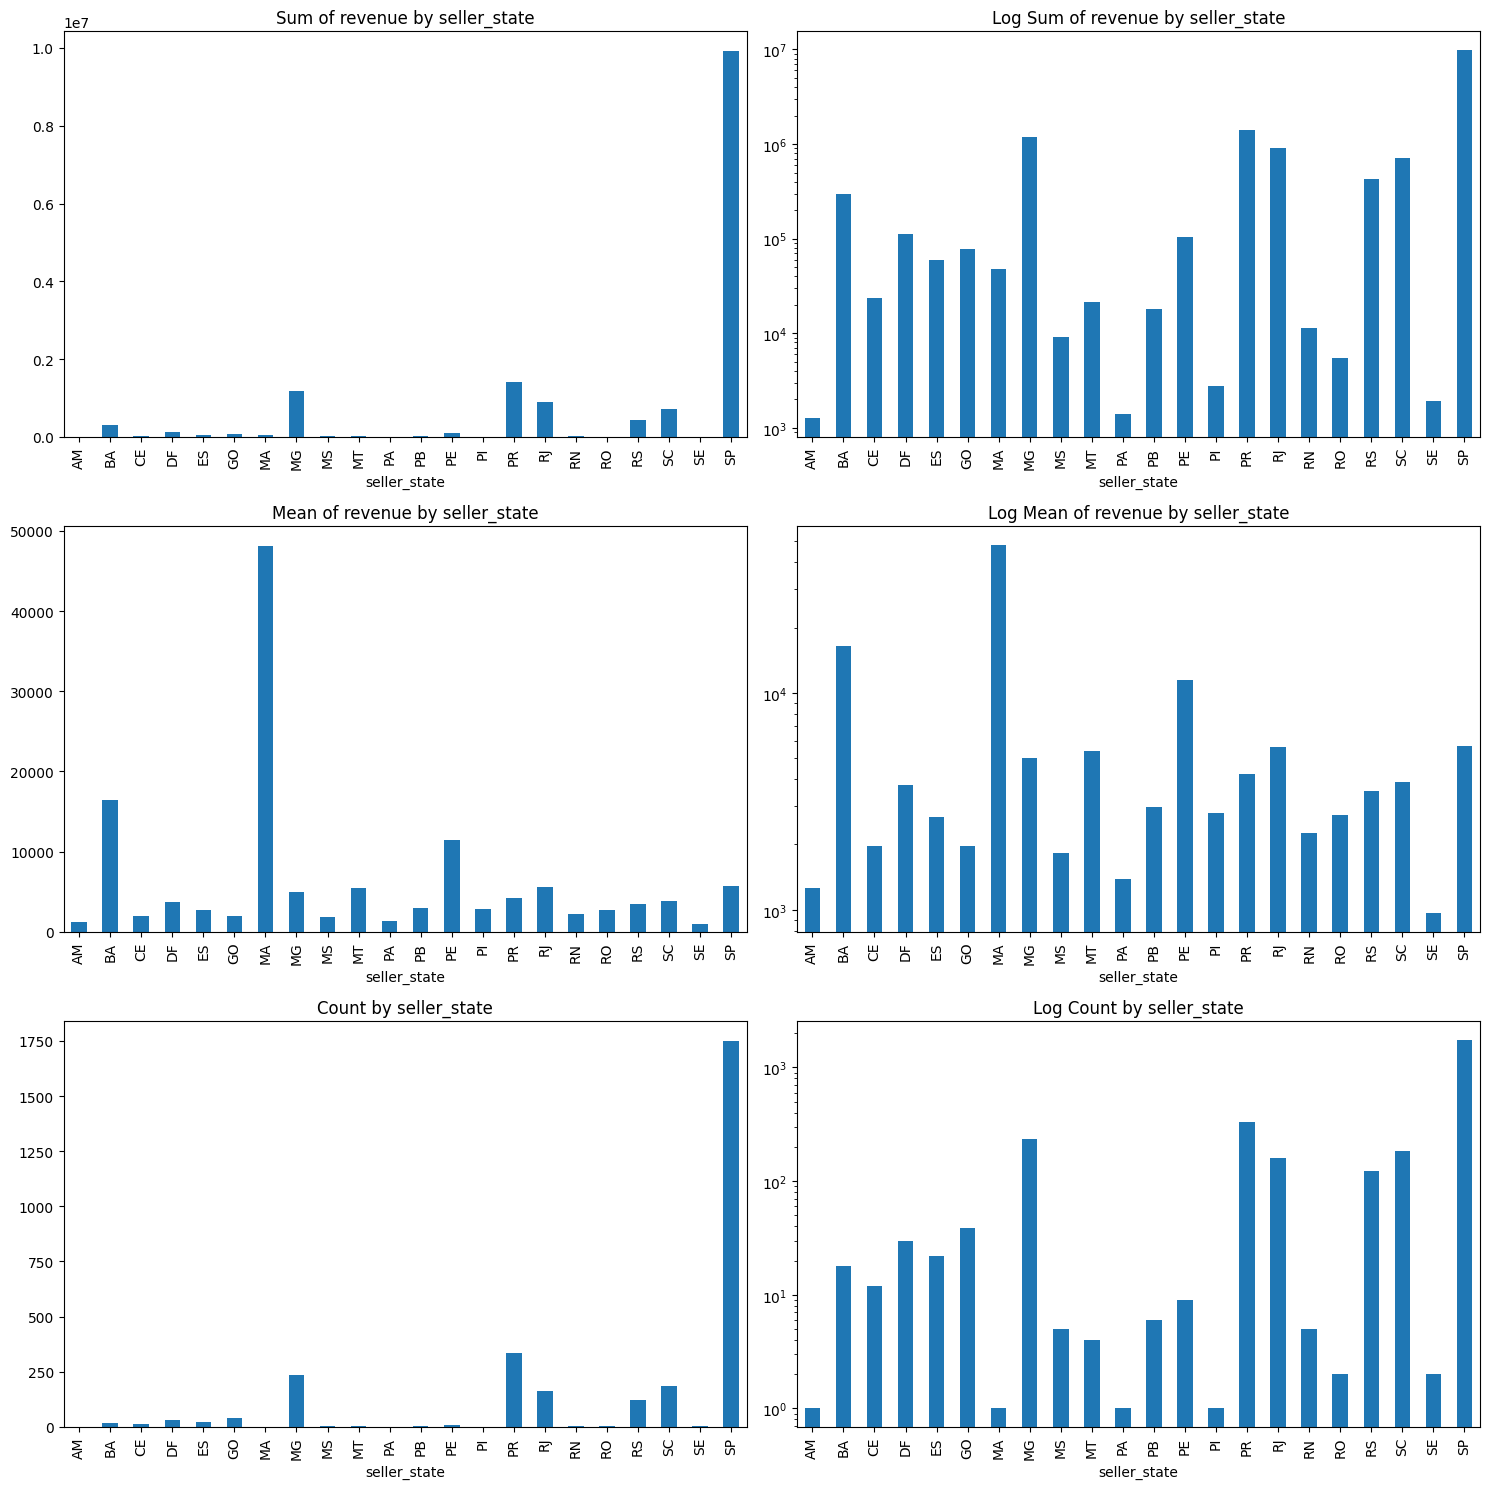

In [3]:
plot_cat(df, 'seller_state', 'revenue', figsize=(15, 15))

### State Record Counts

In [4]:
df.groupby('seller_state')['revenue'].agg('count').sort_values(ascending=False)

seller_state
SP    1751
PR     334
MG     235
SC     184
RJ     161
RS     122
GO      39
DF      30
ES      22
BA      18
CE      12
PE       9
PB       6
MS       5
RN       5
MT       4
SE       2
RO       2
AM       1
PI       1
MA       1
PA       1
Name: revenue, dtype: int64

## 1. Revenue by State

Overview of how revenue is distributed across all seller states: total revenue, mean, and seller count.

- States outside the top 6 have very few sellers. The count drops sharply after the 6th state. Low seller counts may produce unreliable revenue analysis. All remaining states are grouped into "Other" for analysis.
- SP accounts for 64.6% of total revenue. PR is the next largest at 9.2%, followed by MG at 7.7%.
- SP clearly has an effect on revenue, but it's hard to tell from plots alone whether other states have an effect on revenue as well. Kruskal-Wallis will be used to test this.

### Revenue by Top 6 States
SP dominates across all metrics: count, mean, and total revenue are all significantly higher than all other states.

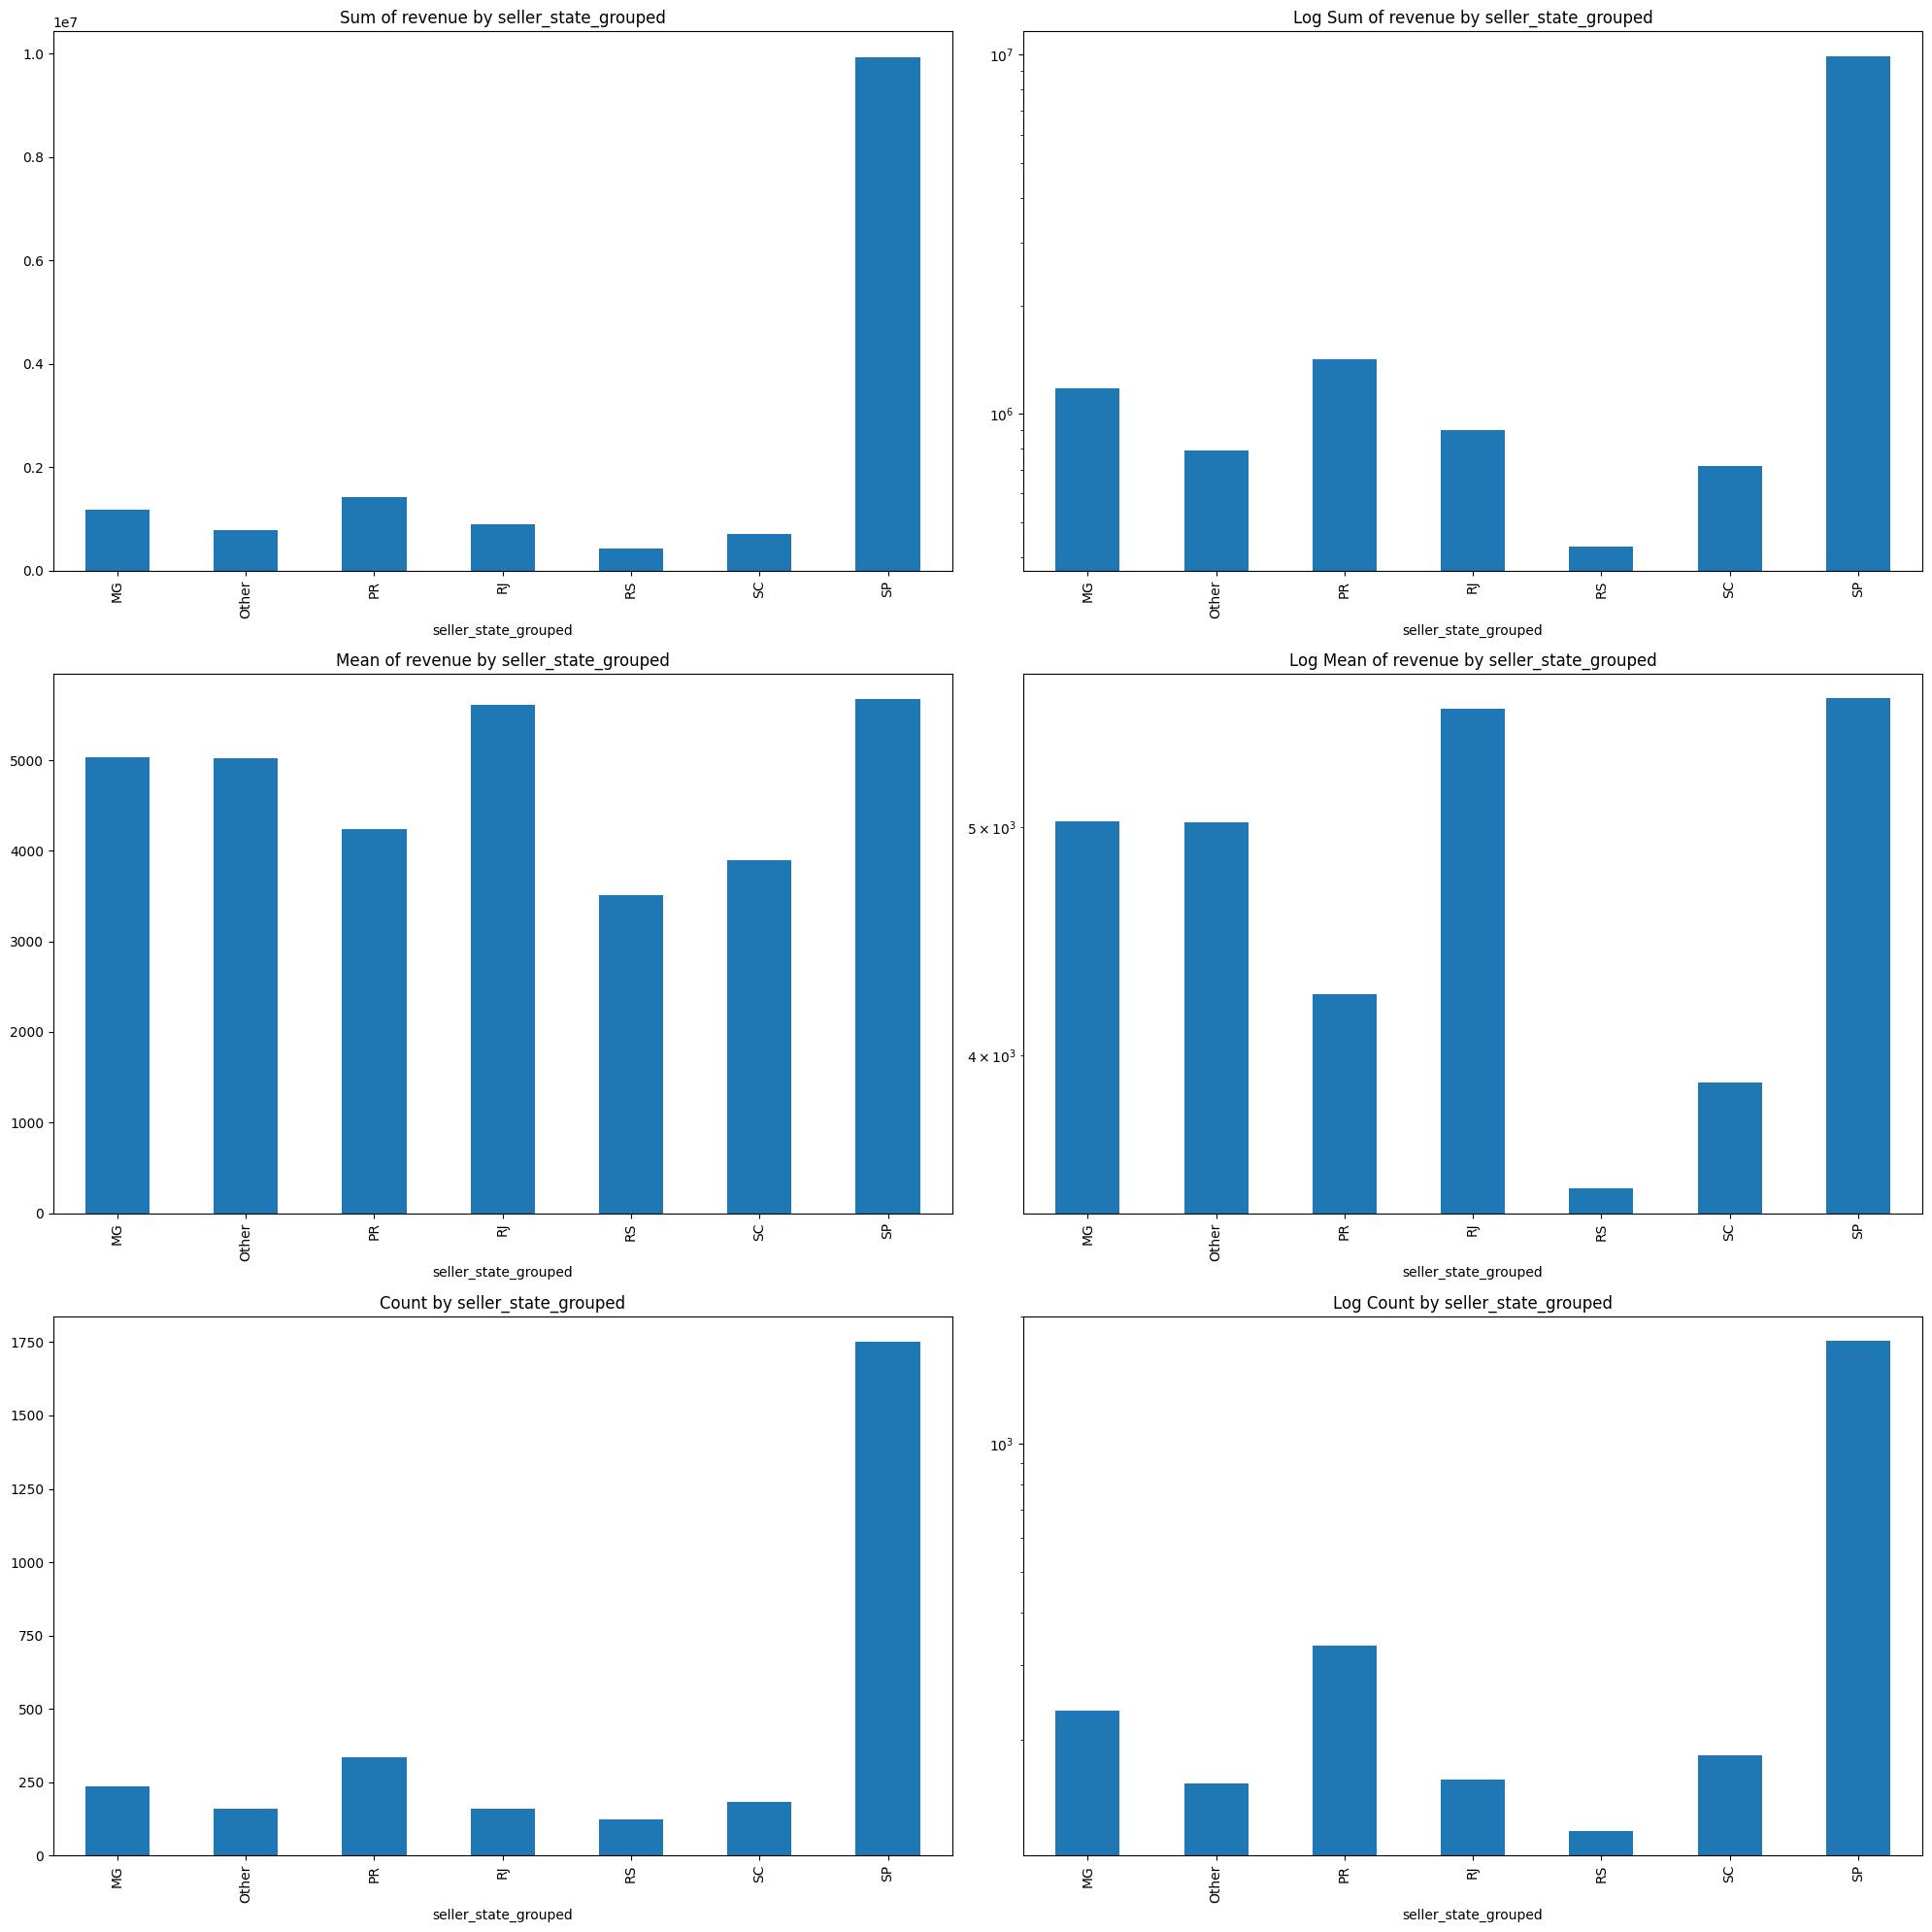

In [5]:
top6_states = df.groupby("seller_state")["revenue"].count().sort_values(ascending=False).head(6).index
df["seller_state_grouped"] = df["seller_state"].where(df["seller_state"].isin(top6_states), other="Other")

plot_cat(df, "seller_state_grouped", "revenue", figsize=(20, 20))

### Revenue by Top 6 States excluding SP
We clearly see the effect SP has on revenue. Removed in this plot to clearly visualize other states.

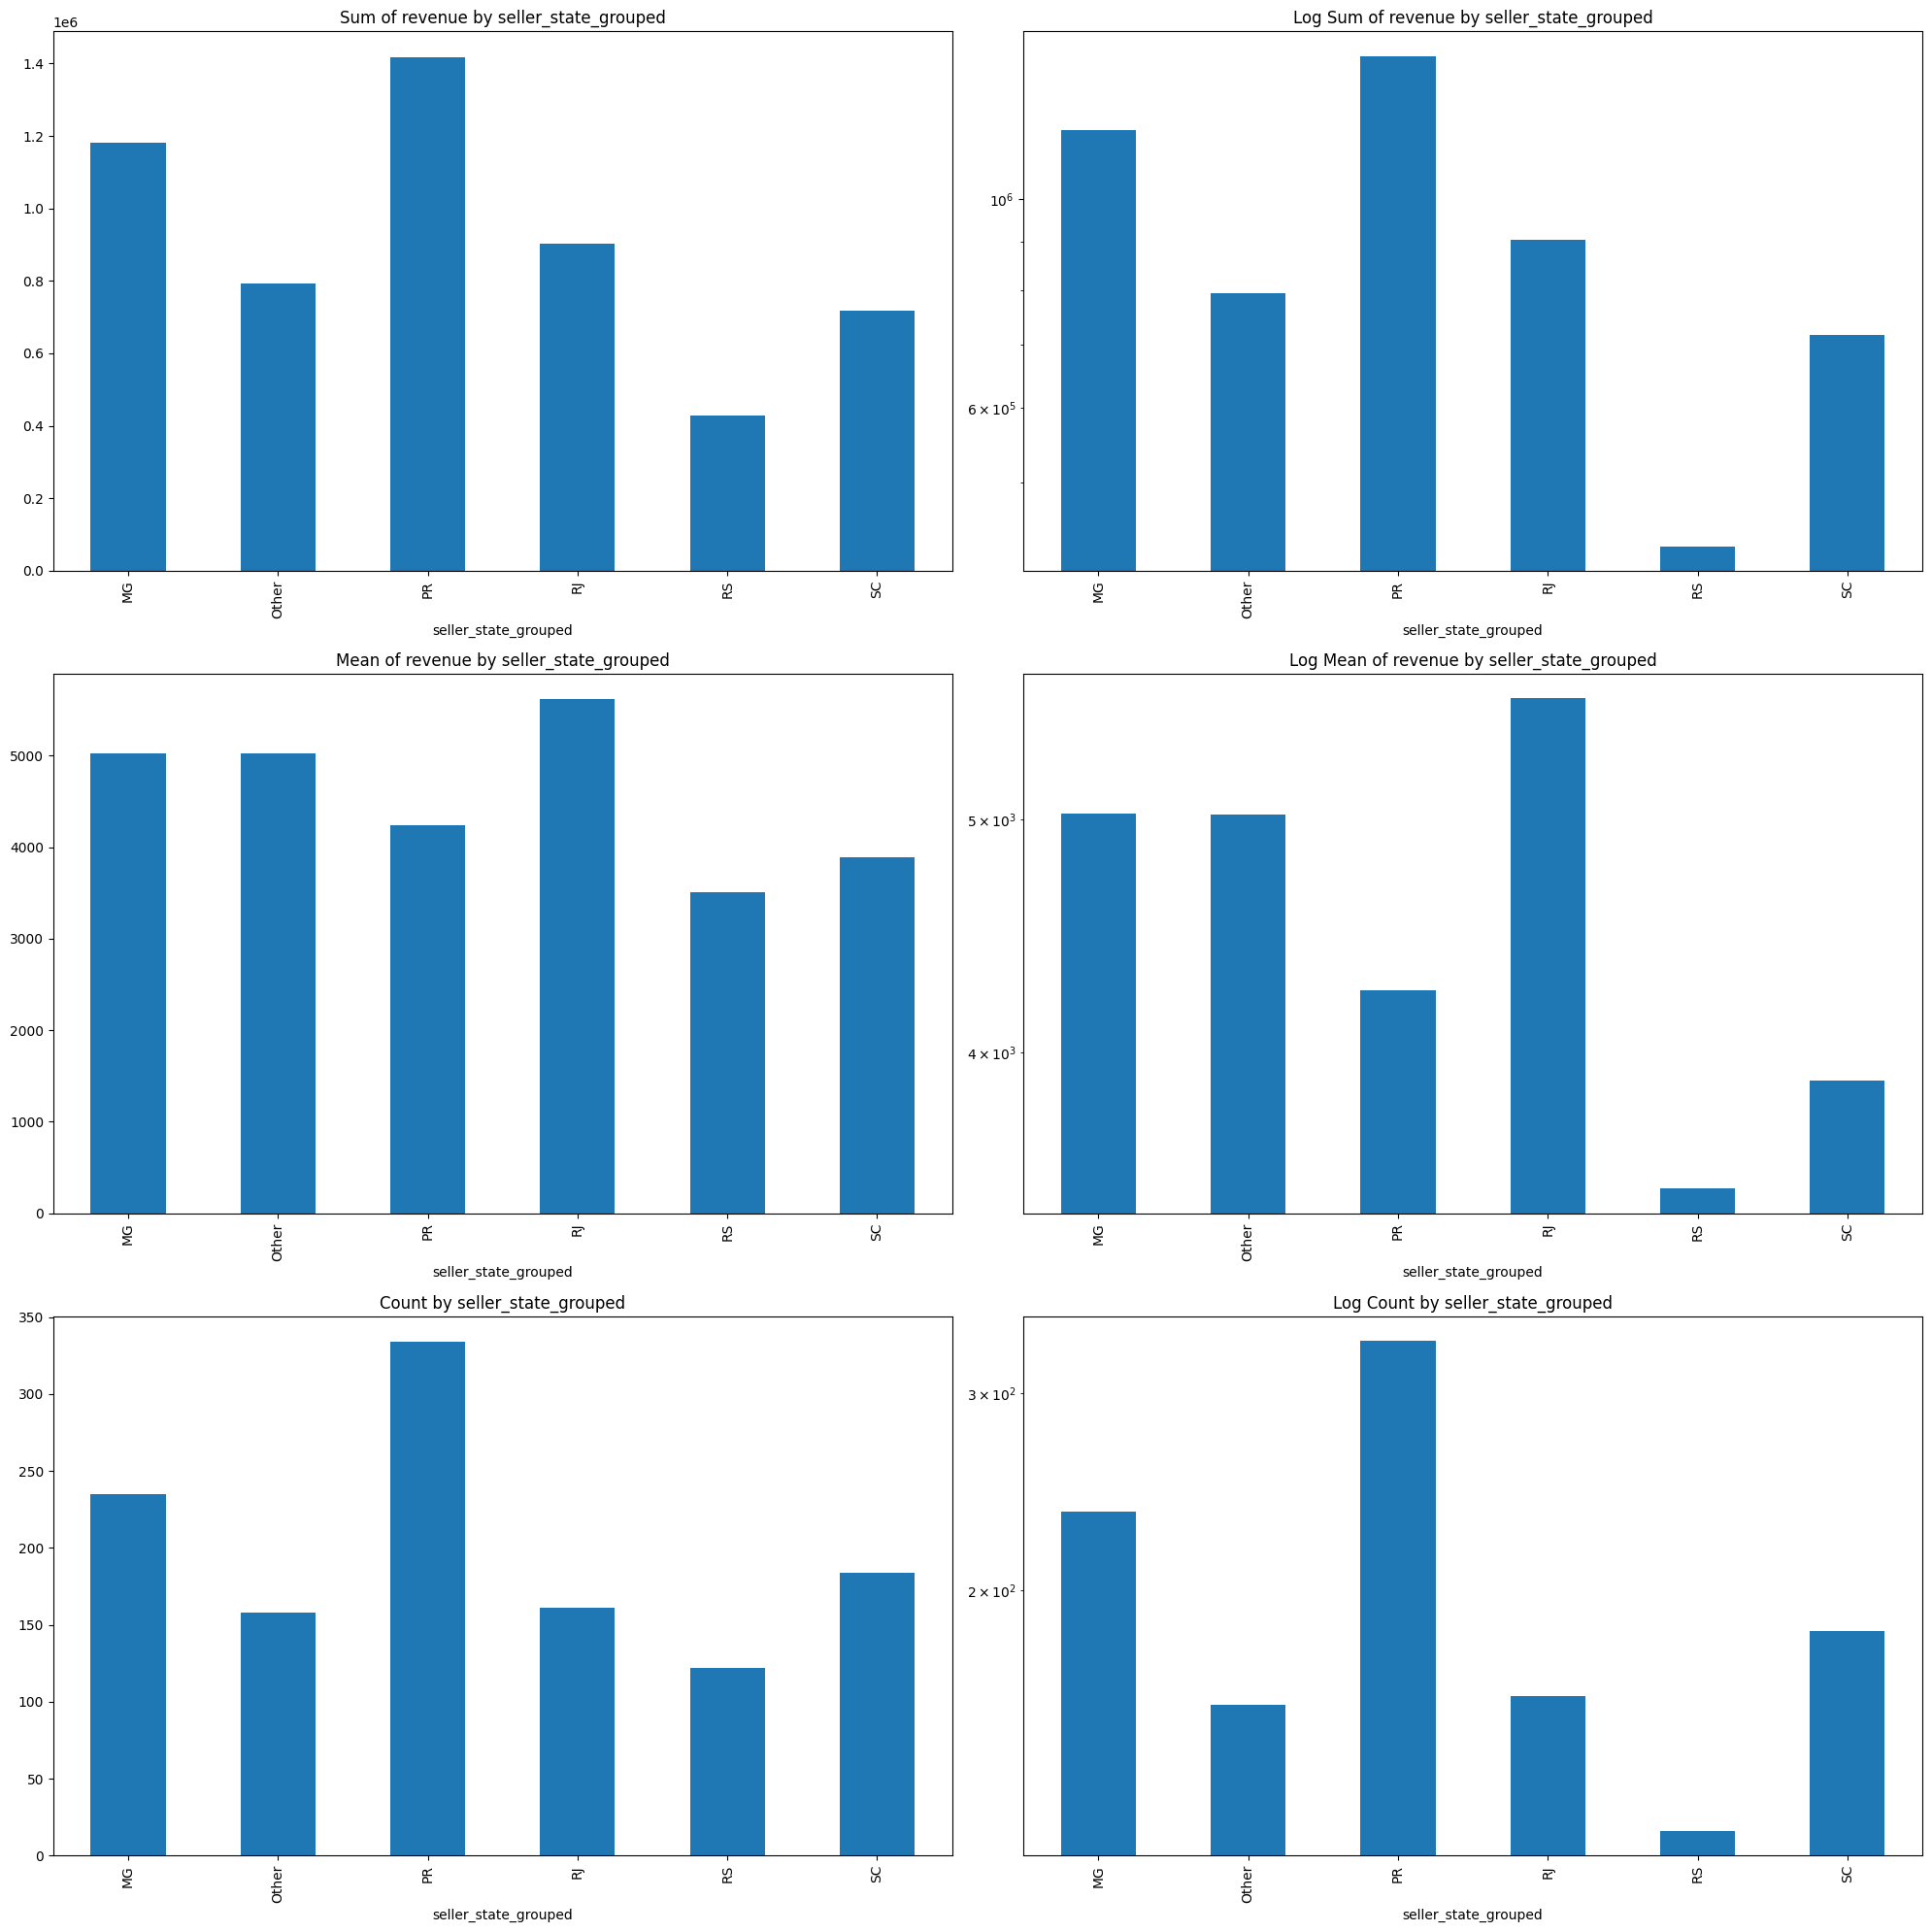

In [6]:
plot_cat(df[df["seller_state_grouped"] != "SP"], "seller_state_grouped", "revenue", figsize=(20, 20))
# Other states apart from SP still do have revenue variations. Statistical tests will be done to check whether these variations are significant

### Revenue % by State
SP accounts for 64.6% of total revenue. The remaining 5 states each contribute between 2.8% and 9.2%, with no single state coming close to SP.

In [7]:
revenue_by_group = df.groupby("seller_state_grouped")["revenue"].sum().sort_values(ascending=False)
revenue_pct = (revenue_by_group / revenue_by_group.sum() * 100).round(1)
print(revenue_pct.to_string())

seller_state_grouped
SP       64.6
PR        9.2
MG        7.7
RJ        5.9
Other     5.2
SC        4.7
RS        2.8


## 2. Revenue Distribution by State
Compare distributions across different states. Plot shows that all states follow the same right-skewed distribution.

### Distribution for Top 6 States
SP has a noticeably wider spread and higher upper outliers than all other states. The remaining states have similar, tightly clustered medians.

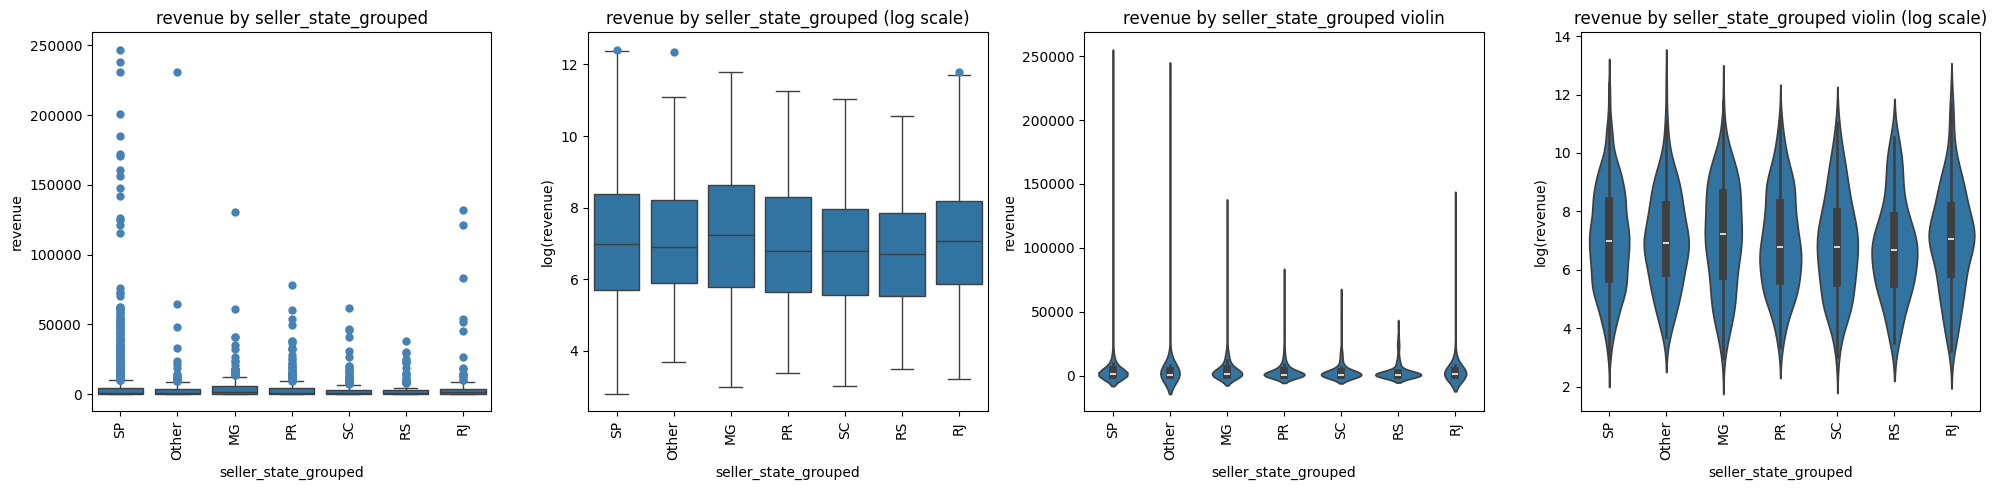

In [8]:
plot_boxplot_by_group(df, "seller_state_grouped", "revenue")

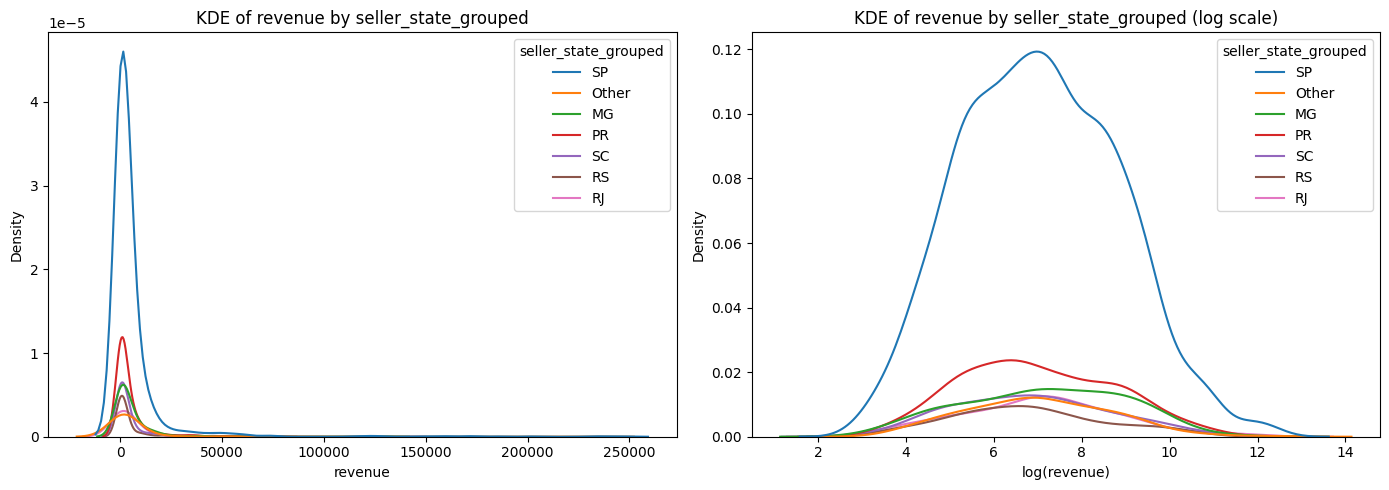

In [9]:
plot_kde_by_group(df, "seller_state_grouped", "revenue")

### Distribution for Top 6 States excluding SP
Without SP, all remaining states show highly similar revenue distributions with comparable medians, consistent with the Kruskal-Wallis result that excludes SP.

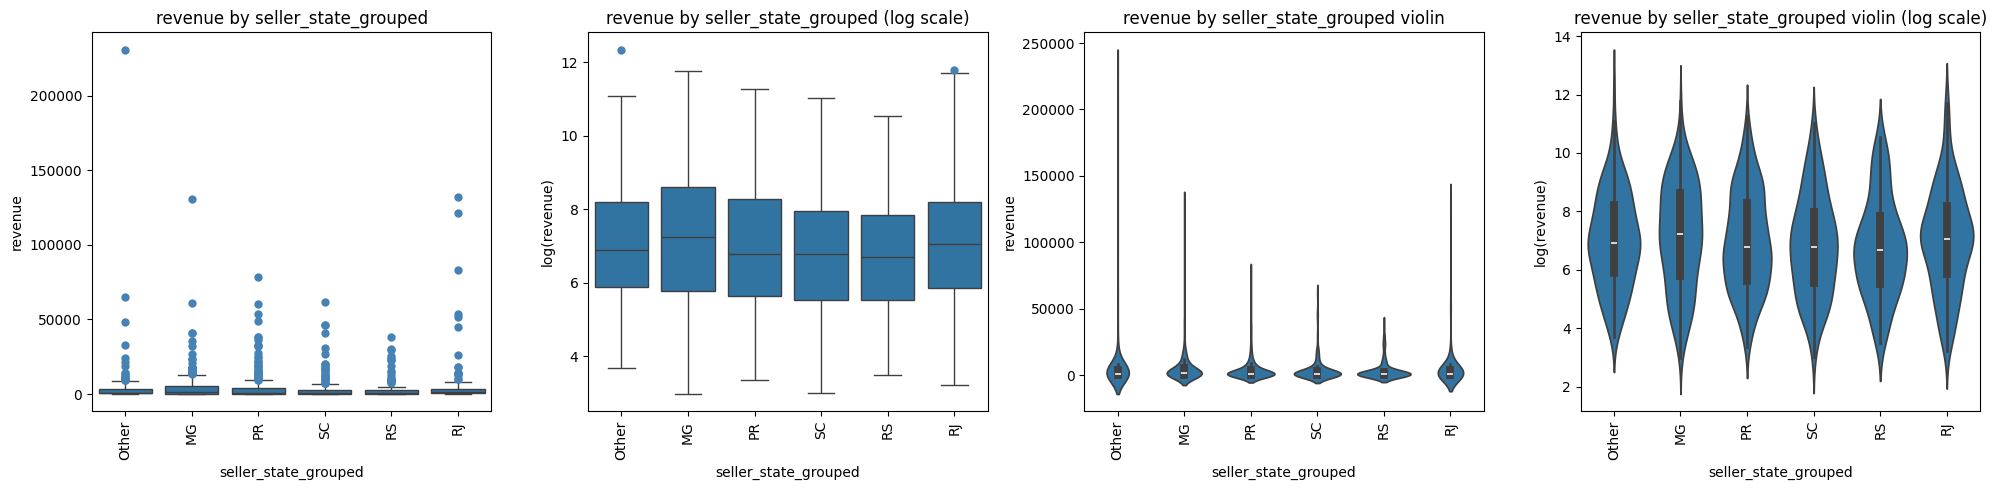

In [10]:
plot_boxplot_by_group(df[df["seller_state_grouped"] != "SP"], "seller_state_grouped", "revenue")

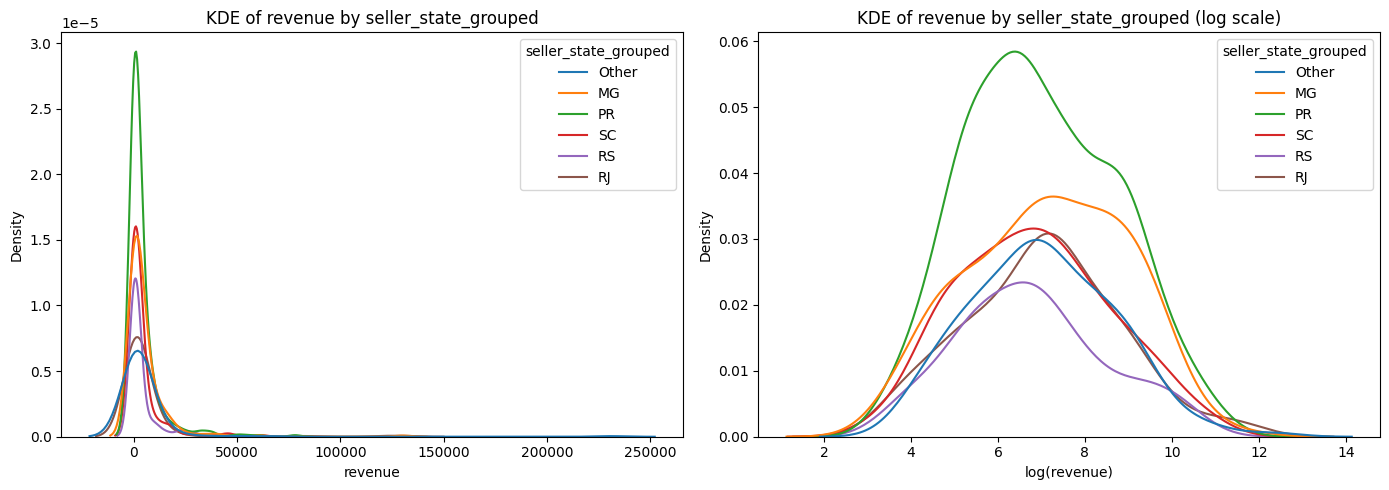

In [11]:
plot_kde_by_group(df[df["seller_state_grouped"] != "SP"], "seller_state_grouped", "revenue")

## 3. State and Revenue Significance Analysis
Kruskal-Wallis shows that there are no significant effects on revenue by state. SP is exlcluded here because we can clearly see from plots that there is significant effects. Kruskal-Wallis is used because data is not normally distributed, but follows the same distribution.

- The effect size (epsilon squared = 0.0012) is near zero, confirming that state explains essentially none of the variance in revenue among the non-SP group.

Tested states include:
- MG
- PR
- SC
- RS
- RJ
- Other

In [12]:
groups_no_sp = [g for g in df["seller_state_grouped"].unique() if g != "SP"]
groups_data = [df.loc[df["seller_state_grouped"] == g, "revenue"].values for g in groups_no_sp]

stat, p = kruskal(*groups_data)

n = sum(len(g) for g in groups_data)
k = len(groups_no_sp)
epsilon_sq = (stat - k + 1) / (n - k)

print(f"Kruskal-Wallis Test:")
print(f"H statistic : {stat:.4f}")
print(f"p-value: {p:.4f}")
print(f"Significant? : {p < 0.05}")
print(f"Effect Size: {epsilon_sq:.4f}")

Kruskal-Wallis Test:
H statistic : 6.3736
p-value: 0.2715
Significant? : False
Effect Size: 0.0012
